# CNN — Classificação de Árvores Binárias (2 classes)

Classes: `balanceada` | `nao_balanceada`

In [ ]:
# @title
from google.colab import drive
import os

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")
else:
    print("Drive já montado.")

Drive já montado.


### Imports e seed

In [ ]:
import os, shutil, math, random, time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report,
    mean_squared_error, roc_auc_score,
    ConfusionMatrixDisplay,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

## Configurações

In [ ]:
IMAGE_SIZE  = (128, 128)
BATCH_SIZE  = 8
EPOCHS      = 100
LR          = 2e-4

CAMINHO_TRABALHO = "/content/drive/MyDrive/Sistemas Inteligentes - Trabalho"
DATASET_ROOT     = f"{CAMINHO_TRABALHO}/dataset"
AUGMENTED_DIR    = f"{CAMINHO_TRABALHO}/dataset_balanceadas_aumentado"
SPLIT_DIR        = f"{CAMINHO_TRABALHO}/dataset_split_v4"

PASTAS_NAO_BAL = [
    "desbalanceadas_direita",
    "desbalanceadas_esquerda",
    "pendentes_direita",
    "pendentes_esquerda",
]

CLASSES     = ["balanceada", "nao_balanceada"]
NUM_CLASSES = 2

## Duplicar balanceadas com espelhamento horizontal

In [ ]:
def duplicar_balanceadas(src_pasta, dst_pasta, seed=SEED):
    if os.path.exists(dst_pasta):
        total = len([f for f in os.listdir(dst_pasta)
                     if f.lower().endswith((".png",".jpg",".jpeg"))])
        if total >= 100:
            print(f"Pasta já existe com {total} imagens — pulando.")
            return
        print(f"Pasta incompleta ({total} imgs) — recriando...")
        shutil.rmtree(dst_pasta)

    os.makedirs(dst_pasta, exist_ok=True)
    arquivos = [f for f in os.listdir(src_pasta)
                if f.lower().endswith((".png",".jpg",".jpeg"))]

    for nome in arquivos:
        src = os.path.join(src_pasta, nome)
        shutil.copy2(src, os.path.join(dst_pasta, nome))
        img = Image.open(src).convert("RGB")
        espelhada = img.transpose(Image.FLIP_LEFT_RIGHT)
        base, ext = os.path.splitext(nome)
        espelhada.save(os.path.join(dst_pasta, f"{base}_flip{ext}"))

    total = len(os.listdir(dst_pasta))
    print(f"Balanceadas: {len(arquivos)} originais + {len(arquivos)} espelhadas = {total} imagens")

src_bal = os.path.join(DATASET_ROOT, "balanceadas")
duplicar_balanceadas(src_bal, AUGMENTED_DIR)

Pasta já existe com 100 imagens — pulando.


##Split 70 / 10 / 20

In [ ]:
def copy_with_retry(src, dst, retries=5, delay=3):
    for attempt in range(retries):
        try:
            shutil.copy2(src, dst); return
        except OSError:
            if attempt < retries - 1:
                print(f"    [retry {attempt+1}] aguardando {delay}s...")
                time.sleep(delay)
            else:
                raise

def split_dataset(dataset_root, aug_dir, dst_root, pastas_nao_bal, seed=SEED):
    if os.path.exists(dst_root):
        total = sum(len(f) for _, _, f in os.walk(dst_root))
        if total >= 200:
            return
        shutil.rmtree(dst_root)

    for split in ("train", "val", "test"):
        for cls in ("balanceada", "nao_balanceada"):
            os.makedirs(os.path.join(dst_root, split, cls), exist_ok=True)

    def coletar_pasta(pasta_path, limite=None):
        arquivos = [f for f in os.listdir(pasta_path)
                    if f.lower().endswith((".png",".jpg",".jpeg"))]
        random.Random(seed).shuffle(arquivos)
        return arquivos[:limite] if limite else arquivos

    def distribuir(lista_src_nome, cls_nome):
        """lista_src_nome: [(caminho_pasta, nome_arquivo), ...]"""
        random.Random(seed).shuffle(lista_src_nome)
        n     = len(lista_src_nome)
        n_tr  = math.floor(n * 0.70)
        n_val = math.floor(n * 0.10)
        buckets = {
            "train": lista_src_nome[:n_tr],
            "val"  : lista_src_nome[n_tr:n_tr+n_val],
            "test" : lista_src_nome[n_tr+n_val:],
        }
        for split, lista in buckets.items():
            for pasta, nome in lista:
                copy_with_retry(
                    os.path.join(pasta, nome),
                    os.path.join(dst_root, split, cls_nome, nome),
                )
        print(f"  {cls_nome.upper()}: {n_tr} treino | {n_val} val | {n-n_tr-n_val} teste  (total={n})")

    bal_imgs = [(aug_dir, f) for f in coletar_pasta(aug_dir)]
    distribuir(bal_imgs, "balanceada")

    nao_bal_imgs = []
    for pasta in pastas_nao_bal:
        caminho = os.path.join(dataset_root, pasta)
        for f in coletar_pasta(caminho):
            nao_bal_imgs.append((caminho, f))
    distribuir(nao_bal_imgs, "nao_balanceada")

split_dataset(DATASET_ROOT, AUGMENTED_DIR, SPLIT_DIR, PASTAS_NAO_BAL)

##Geradores com Data Augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    rescale            = 1.0/255,
    rotation_range     = 25,
    zoom_range         = 0.25,
    width_shift_range  = 0.20,
    height_shift_range = 0.20,
    shear_range        = 0.15,
    brightness_range   = [0.60, 1.40],
    fill_mode          = "nearest",
)

val_test_datagen = ImageDataGenerator(rescale=1.0/255)

def make_gen(datagen, split, shuffle):
    return datagen.flow_from_directory(
        os.path.join(SPLIT_DIR, split),
        target_size = IMAGE_SIZE,
        color_mode  = "grayscale",
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        seed        = SEED,
        shuffle     = shuffle,
    )

train_gen = make_gen(train_datagen,    "train", shuffle=True)
val_gen   = make_gen(val_test_datagen, "val",   shuffle=False)
test_gen  = make_gen(val_test_datagen, "test",  shuffle=False)

Found 210 images belonging to 2 classes.
Found 30 images belonging to 2 classes.
Found 60 images belonging to 2 classes.


##Arquitetura CNN

In [ ]:
def build_model(input_shape=(128, 128, 1), num_classes=2):
    inp = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding="same",
                      kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.15)(x)
    x = layers.Conv2D(64, 3, padding="same",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, padding="same",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.35)(x)

    x = layers.Flatten()(x)

    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.40)(x)

    out = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inp, out, name="CNN_ArvoresBinarias_Corrigida")
    return model

model = build_model(
    input_shape=(128, 128, 1),
    num_classes=NUM_CLASSES,
)

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"],
)

model.summary()
model.summary()

Model: "CNN_Arvores_Dropout_No_Final"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,258 (16.36 MB)

 Trainable params: 4,287,810 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
pesos = compute_class_weight(
    class_weight = "balanced",
    classes      = np.arange(NUM_CLASSES),
    y            = train_gen.classes,
)
class_weights = dict(enumerate(pesos))

##Treinamento

In [ ]:
MODELO_PATH = f"{CAMINHO_TRABALHO}/melhor_modelo_v4.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODELO_PATH,
        monitor="val_loss", save_best_only=True, verbose=1,
    ),
    keras.callbacks.EarlyStopping(
      monitor="val_loss", patience=30,
      restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
      monitor="val_loss", factor=0.5, patience=10,
      min_lr=1e-7, verbose=1,
),
]

history = model.fit(
    train_gen,
    epochs          = EPOCHS,
    validation_data = val_gen,
    class_weight    = class_weights,
    callbacks       = callbacks,
    verbose         = 1,
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3998 - loss: 18.1946
Epoch 1: val_loss improved from None to 1.03057, saving model to /content/drive/MyDrive/Sistemas Inteligentes - Trabalho/melhor_modelo_v4.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Sistemas Inteligentes - Trabalho/melhor_modelo_v4.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.4333 - loss: 21.3073 - val_accuracy: 0.3333 - val_loss: 1.0306 - learning_rate: 0.0010
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4856 - loss: 14.8393
Epoch 2: val_loss improved from 1.03057 to 0.71168, saving model to /content/drive/MyDrive/Sistemas Inteligentes - Trabalho/melhor_modelo_v4.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Sistemas Inteligentes - Trabalho/melhor_modelo_v4.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.5238 - loss: 11.9488 - val_accuracy: 0.6667 - val_loss: 0.7117 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━

##Curvas de aprendizado

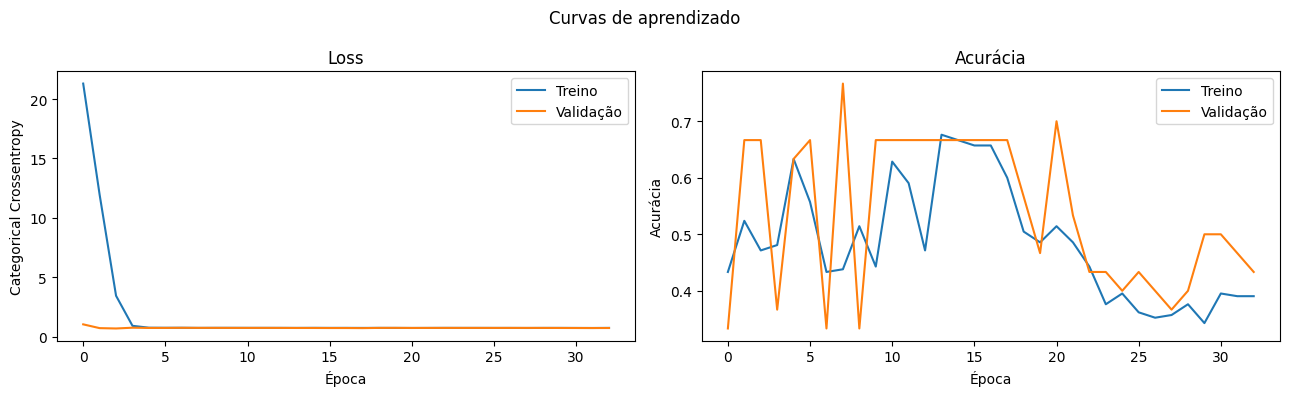

In [ ]:
def plot_history(h):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot(h.history["loss"],     label="Treino")
    ax1.plot(h.history["val_loss"], label="Validação")
    ax1.set_title("Loss"); ax1.set_xlabel("Época")
    ax1.set_ylabel("Categorical Crossentropy"); ax1.legend()

    ax2.plot(h.history["accuracy"],     label="Treino")
    ax2.plot(h.history["val_accuracy"], label="Validação")
    ax2.set_title("Acurácia"); ax2.set_xlabel("Época")
    ax2.set_ylabel("Acurácia"); ax2.legend()

    plt.suptitle("Curvas de aprendizado", fontsize=12)
    plt.tight_layout(); plt.show()

plot_history(history)

##Avaliação no teste

In [ ]:
model = keras.models.load_model(MODELO_PATH)

test_gen.reset()
y_prob = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

loss_t, acc_t = model.evaluate(test_gen, verbose=0)
print(f"\n  Loss  (teste): {loss_t:.4f}")
print(f"  Acurácia (teste): {acc_t:.4f}  ({acc_t*100:.2f}%)")

print("\n── Classification Report ──")
print(classification_report(y_true, y_pred, target_names=class_names))

8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step

  Loss  (teste): 0.6808
  Acurácia (teste): 0.6667  (66.67%)

── Classification Report ──
                precision    recall  f1-score   support

    balanceada       0.00      0.00      0.00        20
nao_balanceada       0.67      1.00      0.80        40

      accuracy                           0.67        60
     macro avg       0.33      0.50      0.40        60
  weighted avg       0.44      0.67      0.53        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Matriz de Confusão

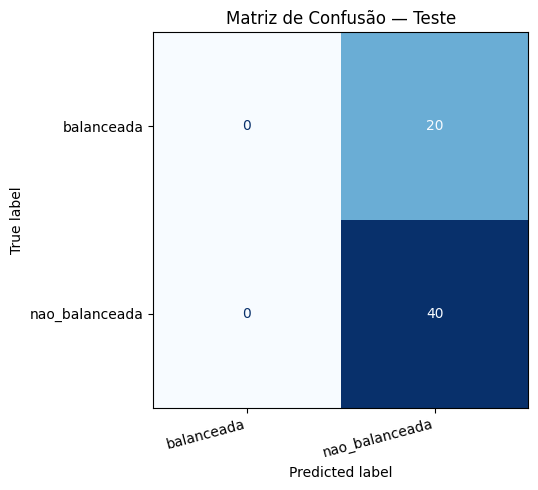

In [ ]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_xticklabels(class_names, rotation=15, ha="right")
plt.title("Matriz de Confusão — Teste"); plt.tight_layout(); plt.show()

### Métricas adicionais

In [ ]:
mse = mean_squared_error(y_true, y_pred)
print(f"  MSE (classes): {mse:.4f}")

try:
    auc = roc_auc_score(y_true, y_prob[:, 1])
    print(f"  AUC-ROC: {auc:.4f}")
except Exception as e:
    print(f"  AUC-ROC: {e}")

print("\nMétricas por classe")
tp = np.diag(cm)
fn = cm.sum(axis=1) - tp
fp = cm.sum(axis=0) - tp
tn = cm.sum() - (tp + fn + fp)
for i, cls in enumerate(class_names):
    sens = tp[i] / (tp[i] + fn[i] + 1e-9)
    spec = tn[i] / (tn[i] + fp[i] + 1e-9)
    prec = tp[i] / (tp[i] + fp[i] + 1e-9)
    f1   = 2 * prec * sens / (prec + sens + 1e-9)
    print(f"  {cls:<20} sens={sens:.3f}  spec={spec:.3f}  prec={prec:.3f}  F1={f1:.3f}")

bal_acc = np.mean(tp / (tp + fn + 1e-9))
print(f"\n  Acurácia balanceada: {bal_acc:.4f}")

  MSE (classes): 0.3333
  AUC-ROC: 0.4738

Métricas por classe
  balanceada           sens=0.000  spec=1.000  prec=0.000  F1=0.000
  nao_balanceada       sens=1.000  spec=0.000  prec=0.667  F1=0.800

  Acurácia balanceada: 0.5000


### Exemplos de predições

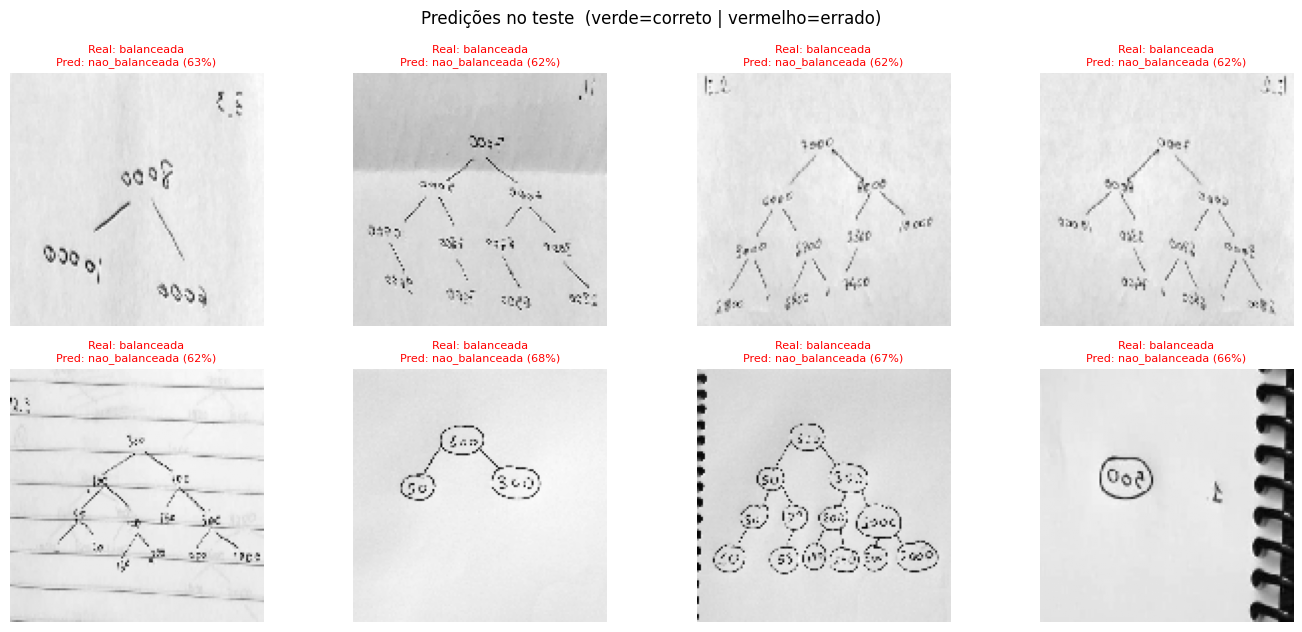

In [ ]:
def plot_predictions(gen, model, n=12):
    gen.reset()
    imgs, labels = next(gen)
    n = min(n, len(imgs))
    preds = model.predict(imgs, verbose=0)
    cols, rows = 4, math.ceil(n / 4)
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.2))
    class_names_local = list(gen.class_indices.keys())
    for i, ax in enumerate(axes.flat):
        if i >= n: ax.axis("off"); continue
        ax.imshow(imgs[i].squeeze(), cmap="gray")
        true_cls = class_names_local[np.argmax(labels[i])]
        pred_cls = class_names_local[np.argmax(preds[i])]
        conf = np.max(preds[i])
        color = "green" if true_cls == pred_cls else "red"
        ax.set_title(f"Real: {true_cls}\nPred: {pred_cls} ({conf:.0%})",
                     fontsize=8, color=color)
        ax.axis("off")
    plt.suptitle("Predições no teste  (verde=correto | vermelho=errado)")
    plt.tight_layout(); plt.show()

plot_predictions(test_gen, model, n=12)